# Non-Markovian HEOM dynamics on one continuous quantum grid

One state goes in at $t=0$, one fixed gate is applied $n$ times, one state comes
out at $t=n\Delta t$.  No intermediate tomography, no re-preparation, and -- the
point of this folder -- **not a single time step of the trajectory is computed
on the classical computer**.

The benchmark throughout is qutip's own `HEOMSolver` and nothing else, so every
number below says how far the grid is from the exact result rather than from
some other approximation.

| step | cost | scales with the number of time steps? |
|---|---|---|
| assemble $A$ | from qutip | no |
| Lyapunov solve (3.2) | $O(n^3)$, $\approx90$ s at $n=2640$ | no |
| $P=e^{A\Delta\tau}$ | $O(n^3)$, $\approx37$ s | no |
| Arnoldi (4.1) | $m$ matrix-vector products | no |
| dilation (2.1) | $O(m^3)$, $m\le128$ | no |
| **propagation** | $n$ applications of one gate on $\lceil\log_2m\rceil+1$ qubits | **on the grid** |

Classically propagated time steps: **zero**, for any $T$.  The companion route
needs $K$ of them before it can start, and a direct classical solve needs all
$n$ of them.

In [1]:
import os, sys, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from heom_gauge import (build_grid, regrid, save_grid, load_grid,
                        qutip_reference, reference_trajectory,
                        companion_baseline, post_selection_curve,
                        qutip_reference_rho)
from gauge_circuit import (build_circuit, run_grid, run_grid_final,
                           run_grid_shots, run_grid_counts,
                           run_grid_counts_offdiagonal, offdiag_readout_cost)

PIC, DATA = 'pictures', 'data'
os.makedirs(PIC, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

In [2]:
# ---- physical constants (energies in cm^-1, time tau = 2*pi*c*t in cm) ----
_C_CM = 2.99792458e10                    # speed of light [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] per t[fs]
KB_CM = 0.6950348004                     # Boltzmann constant [cm^-1/K]

# The one-off construction is O(n^3) in n = N_ADO * d^2, and the Lyapunov
# solve needs several n x n matrices in memory at once.  N=4 / depth 3 gives
# 165 ADOs -> n = 2640 (~110 MB per matrix), which is comfortable.  N=7 forces
# depth 2 (120 ADOs -> n = 5880, ~550 MB per matrix and roughly half an hour);
# N=7 at depth 3 is 680 ADOs -> n = 33320, i.e. ~18 GB per matrix, out of reach.
N = 4                                    # 4-site or 7-site FMO
if N == 4:
    H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                      [-87.7, 12495.0,  30.8,   8.2],
                      [5.5,      30.8, 12175.0, -53.4],
                      [-5.9,      8.2, -53.4, 12285.0]])
elif N == 7:
    H_FMO = np.array([[1410.0, -87.7, 5.5, -5.9, 6.7, -13.7, -9.9],
                      [-87.7, 1530.0, 30.8, 8.2, 0.7, 11.8, 4.3],
                      [5.5, 30.8, 1210.0, -53.5, -2.2, -9.6, 6.0],
                      [-5.9, 8.2, -53.5, 1320.0, -70.7, -17.0, -63.3],
                      [6.7, 0.7, -2.2, -70.7, 1480.0, 81.1, -1.3],
                      [-13.7, 11.8, -9.6, -17.0, 81.1, 1630.0, 39.7],
                      [-9.9, 4.3, 6.0, -63.3, -1.3, 39.7, 1440.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 50.0, 300.0

MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

rho0 = np.diag([1.0] + [0.0] * (N - 1))   # excitation on site 1

dt_fs      = 10.0
HEOM_depth = 3
N_STEPS    = 100          # 1 ps
DELTA      = 0.02       # Lyapunov shift [cm^-1], eq. (3.2); only needs delta*T << 1
M_KRYLOV   = 128          # Krylov dimension, eq. (4.1)
SHOTS      = 512          # only p_t is statistical -- the state is not (Prop. 7)

t_fs = np.arange(N_STEPS + 1) * dt_fs
cols = plt.cm.tab10(np.arange(N))
print(f"{N}-site FMO, dt = {dt_fs} fs, T = {t_fs[-1]:.0f} fs, HEOM depth {HEOM_depth}")

4-site FMO, dt = 10.0 fs, T = 1000 fs, HEOM depth 3


## 7  Build the grid

Everything in this cell is done **once** and none of it scales with the number
of time steps: the HEOM generator, one Lyapunov solve, one matrix exponential,
$m$ Arnoldi matrix-vector products and one dilation.

In [3]:
t0 = time.time()
grid = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV, depth=HEOM_depth, **MODEL)
print(f"one-off construction: {time.time() - t0:.1f} s")
save_grid(f'{DATA}/grid_N{N}_m{grid["m"]}.npz', grid)

P, Pt = grid['P'], grid['Pt']
A_herm = 0.5 * (grid['A'] + grid['A'].conj().T)
print()
print(f"  ||P||_2                = {np.linalg.norm(P, 2):12.4f}")
print(f"  spectral radius rho(P) = {max(abs(np.linalg.eigvals(grid['Hm']))):12.6f}")
print(f"  numerical abscissa     = {np.linalg.eigvalsh(A_herm).max():12.4e} cm^-1  (eq. 2.3)")
print(f"  ||P~||_2               = {np.linalg.norm(Pt, 2):12.6f}   "
      f"bound e^(delta dt) = {np.exp(DELTA * grid['dt_cm']):.6f}")
print(f"  cond(W)                = {grid['gauge']['cond']:12.3e}")
print(f"  grid                   = {grid['n_qubits']} qubits, one "
      f"{2*grid['mp']}x{2*grid['mp']} gate")
print(f"  Sz.-Nagy scale s       = {grid['s']:.8f}   "
      f"s^{N_STEPS} = {grid['s']**N_STEPS:.4f}")

  A: 2640 x 2640 (165 ADOs)
  gauge delta=0.02 cm^-1: cond(W)=1.74e+10, ||P||=32.3922 -> ||P~||=1.000038 (bound 1.000038)
  Krylov m=128 -> 8 qubits, ||H_m||=1.000038, s=1.000038, s^100=1.0038
one-off construction: 80.6 s

  ||P||_2                =      32.3922
  spectral radius rho(P) =     1.000000
  numerical abscissa     =   2.6135e+03 cm^-1  (eq. 2.3)
  ||P~||_2               =     1.000038   bound e^(delta dt) = 1.000038
  cond(W)                =    1.739e+10
  grid                   = 8 qubits, one 256x256 gate
  Sz.-Nagy scale s       = 1.00003767   s^100 = 1.0038


## 8  The benchmark: qutip's own `HEOMSolver`

The only reference used anywhere in this folder.

In [4]:
t0 = time.time()
pops_qutip = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)
print(f"qutip HEOMSolver: {time.time() - t0:.2f} s, {pops_qutip.shape}")

10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.05s. Est. time left: 00:00:00:00
30.0%. Run time:   0.07s. Est. time left: 00:00:00:00
40.0%. Run time:   0.10s. Est. time left: 00:00:00:00
50.0%. Run time:   0.12s. Est. time left: 00:00:00:00
60.0%. Run time:   0.14s. Est. time left: 00:00:00:00
70.0%. Run time:   0.16s. Est. time left: 00:00:00:00
80.0%. Run time:   0.18s. Est. time left: 00:00:00:00
90.0%. Run time:   0.20s. Est. time left: 00:00:00:00
100.0%. Run time:   0.22s. Est. time left: 00:00:00:00
Total run time:   0.22s
qutip HEOMSolver: 0.24 s, (101, 4)


## 9  The grid, in Qiskit

One circuit, `N_STEPS` repetitions of the single gate $U$, the ancilla measured
into its own classical bit and reset after each.  Every intermediate time is
read out of that **one** run through `save_statevector(conditional=True)`.

Two readouts are reported.  `pops_tr` normalises the accepted branch with
$\operatorname{Tr}\rho_S(t)=1$; by Proposition 7 that branch is exact, so this
readout carries no statistical error at all.  `pops` instead restores
$\lVert y_t\rVert$ from the acceptance rate via (5.1) and therefore fluctuates
with $1/\sqrt{N_{\rm acc}}$ -- section 15 shows it converging.  The two use
disjoint information, so their agreement is a self-contained check on sections
3-5.

`run_grid` reads every stored time out of one circuit via
`save_statevector(conditional=True)`.  `run_grid_shots` instead builds a fresh
circuit for each read-out time, measures the ancilla into its own classical bit
after every step, and estimates $p_{\rm total}(t)$ from the *counts* --- the
fraction of shots whose record is all zeros.  That estimate is binomial, so it
carries the usual $1/\sqrt{N}$ error, and the error bars below are propagated
through $\lVert y_t\rVert = s^t\sqrt{p_t}\lVert y_0\rVert$ via
$\delta\!\sqrt{p}/\!\sqrt{p} = \delta p/(2p)$.


In [5]:
t0 = time.time()
pops_grid, pops_tr, info = run_grid(grid, N_STEPS, shots=SHOTS, save_every=1)
print(f"  simulation: {time.time() - t0:.1f} s")

idx = info['t_index']
err_grid = np.abs(pops_tr - pops_qutip[idx]).max()
err_p    = np.abs(pops_grid - pops_qutip[idx]).max()
print()
print(f"  QUANTUM GRID vs qutip HEOMSolver          : {err_grid:.3e}")
print(f"  same, norm from the record (eq. 5.1)      : {err_p:.3e}   "
      f"({SHOTS} shots)")
print(f"  post-selection probability                : {info['p_success'][0]:.4f} -> "
      f"{info['p_success'][-1]:.4f}")

  grid: 8 qubits, 100 applications of one gate, circuit depth 300, 512 shots
  post-selection probability: 1.0000 -> 0.3418
  simulation: 1.8 s

  QUANTUM GRID vs qutip HEOMSolver          : 5.268e-07
  same, norm from the record (eq. 5.1)      : 1.540e-02   (512 shots)
  post-selection probability                : 1.0000 -> 0.3418


10.0%. Run time:   0.03s. Est. time left: 00:00:00:00
20.0%. Run time:   0.06s. Est. time left: 00:00:00:00
30.0%. Run time:   0.09s. Est. time left: 00:00:00:00
40.0%. Run time:   0.12s. Est. time left: 00:00:00:00
50.0%. Run time:   0.14s. Est. time left: 00:00:00:00
60.0%. Run time:   0.17s. Est. time left: 00:00:00:00
70.0%. Run time:   0.20s. Est. time left: 00:00:00:00
80.0%. Run time:   0.22s. Est. time left: 00:00:00:00
90.0%. Run time:   0.24s. Est. time left: 00:00:00:00
100.0%. Run time:   0.26s. Est. time left: 00:00:00:00
Total run time:   0.26s
ausgewaehlte Offdiagonalelemente: ['rho_12', 'rho_23', 'rho_14', 'rho_13']
  Diagonale    : Tr-Ablesung 5.268e-07   |  (5.1)-Ablesung 1.540e-02
  Kohaerenzen  : Tr-Ablesung 3.711e-07   |  (5.1)-Ablesung 3.877e-03


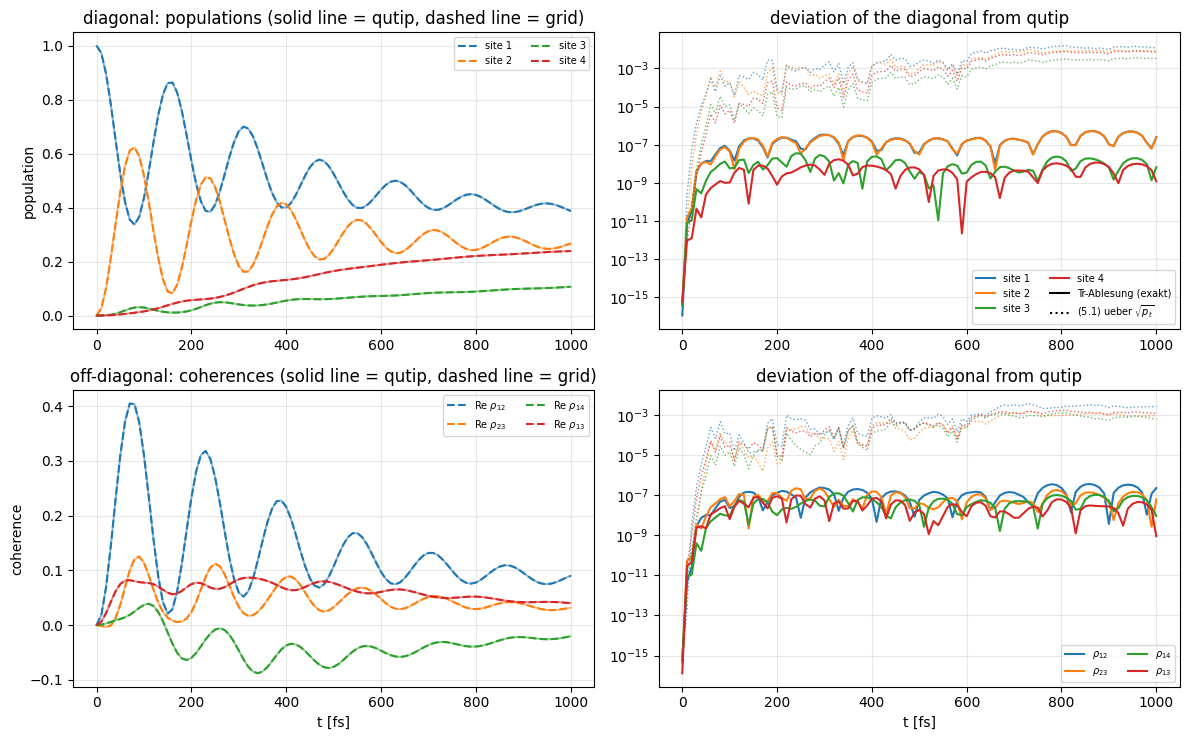

In [20]:
rho_ref = qutip_reference_rho(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)
jr    = info['t_index']
rho_n = info['rho_tr']          # spur-normiert: p_t kuerzt sich heraus -> exakt
rho_p = info['rho']             # ueber eq. (5.1), also mit sqrt(p_t) aus den Counts
rerr  = info['rho_err']         # Fehlerbalken der (5.1)-Route
okr   = np.isfinite(pops_grid[:, 0])

iu  = [(i, j) for i in range(N) for j in range(i + 1, N)]
sel = [iu[k] for k in np.argsort([np.abs(np.real(rho_ref[:, i, j])).max()
                                  for i, j in iu])[::-1][:4]]
dev = lambda a, i, j: np.abs(np.real(a[okr, i, j]) - np.real(rho_ref[jr[okr], i, j]))
print("ausgewaehlte Offdiagonalelemente:", [f"rho_{i+1}{j+1}" for i, j in sel])
print(f"  Diagonale    : Tr-Ablesung "
    f"{np.max([dev(rho_n, i, i) for i in range(N)]):.3e}"
    f"   |  (5.1)-Ablesung "
    f"{np.max([dev(rho_p, i, i) for i in range(N)]):.3e}")

print(f"  Kohaerenzen  : Tr-Ablesung "
    f"{np.max([dev(rho_n, i, j) for i, j in sel]):.3e}"
    f"   |  (5.1)-Ablesung "
    f"{np.max([dev(rho_p, i, j) for i, j in sel]):.3e}")

fig, ax = plt.subplots(2, 2, figsize=(12, 7.5))

for i in range(N):                                   # oben links: Diagonale
    ax[0, 0].plot(t_fs, np.real(rho_ref[:, i, i]), color=cols[i], lw=1.4, alpha=.55)
    ax[0, 0].plot(jr[okr] * dt_fs, np.real(rho_n[okr, i, i]), '--', ms=4,
                  color=cols[i], label=f'site {i+1}')
ax[0, 0].set_ylabel('population')
ax[0, 0].set_title('diagonal: populations (solid line = qutip, dashed line = grid)')
ax[0, 0].legend(fontsize=7, ncol=2); ax[0, 0].grid(alpha=.3)

for i in range(N):                                   # oben rechts: beide Fehler
    ax[0, 1].semilogy(jr[okr] * dt_fs, dev(rho_n, i, i) + 1e-18, '-', ms=3,
                      color=cols[i], label=f'site {i+1}')
    ax[0, 1].semilogy(jr[okr] * dt_fs, dev(rho_p, i, i) + 1e-18, ':', lw=1,
                      color=cols[i], alpha=.7)
ax[0, 1].plot([], [], 'k-', label='Tr-Ablesung (exakt)')
ax[0, 1].plot([], [], 'k:', label=r'(5.1) ueber $\sqrt{p_t}$')
ax[0, 1].set_title('deviation of the diagonal from qutip')
ax[0, 1].legend(fontsize=7, ncol=2); ax[0, 1].grid(alpha=.3, which='both')

for n, (i, j) in enumerate(sel):                     # unten links: Offdiagonale
    ax[1, 0].plot(t_fs, np.real(rho_ref[:, i, j]), color=cols[n], lw=1.4, alpha=.55)
    ax[1, 0].plot(jr[okr] * dt_fs, np.real(rho_n[okr, i, j]), '--', ms=4,
                  color=cols[n], label=rf'Re $\rho_{{{i+1}{j+1}}}$')
ax[1, 0].set_xlabel('t [fs]'); ax[1, 0].set_ylabel('coherence')
ax[1, 0].set_title('off-diagonal: coherences (solid line = qutip, dashed line = grid)')
ax[1, 0].legend(fontsize=7, ncol=2); ax[1, 0].grid(alpha=.3)

for n, (i, j) in enumerate(sel):                     # unten rechts: beide Fehler
    ax[1, 1].semilogy(jr[okr] * dt_fs, dev(rho_n, i, j) + 1e-18, '-', ms=3,
                      color=cols[n], label=rf'$\rho_{{{i+1}{j+1}}}$')
    ax[1, 1].semilogy(jr[okr] * dt_fs, dev(rho_p, i, j) + 1e-18, ':', lw=1,
                      color=cols[n], alpha=.7)
ax[1, 1].set_xlabel('t [fs]')
ax[1, 1].set_title('deviation of the off-diagonal from qutip')
ax[1, 1].legend(fontsize=7, ncol=2); ax[1, 1].grid(alpha=.3, which='both')

fig.tight_layout(); fig.savefig(f'{PIC}/offdiag_N{N}.png', dpi=160)
plt.show()

### Hier muss ein delta von ungefähr 0.02 und eventuell scaled_ados = False verwendet werden.

  t=   0  p_succ=1.0000  Spur=1.0298
  t=  20  p_succ=0.9167  Spur=1.0040
  t=  40  p_succ=0.6828  Spur=1.0112
  t=  60  p_succ=0.5043  Spur=0.9536
  t=  80  p_succ=0.4029  Spur=1.0061
  t= 100  p_succ=0.3634  Spur=1.0001
  simulation: 275.3 s

  shot-based vs qutip : 3.117e-02
  typical error bar   : 1.104e-02


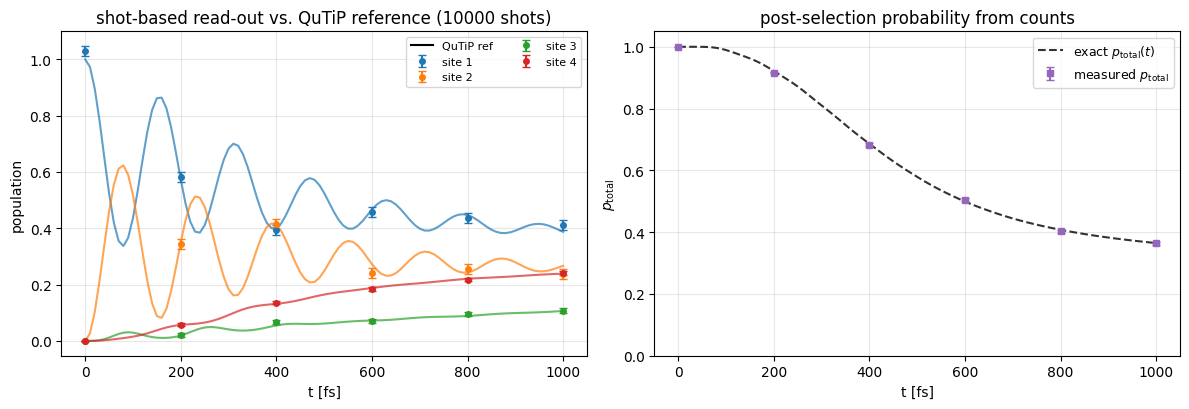

In [30]:
SHOTS_S, EVERY_S = 10_000, 20

t0 = time.time()
pops_s, err_s, info_s = run_grid_counts(grid, N_STEPS, shots=SHOTS_S,
                                       save_every=EVERY_S)
print(f"  simulation: {time.time() - t0:.1f} s")
js = info_s['t_index']
ok_s = np.isfinite(pops_s[:, 0])
print(f"\n  shot-based vs qutip : {np.abs(pops_s[ok_s] - pops_qutip[js[ok_s]]).max():.3e}")
print(f"  typical error bar   : {np.nanmean(err_s[ok_s]):.3e}")
#print(f"  accepted shots      : {info_s['accepted'][ok_s]}")

# Theoretische Referenzkurve direkt aus den Grid-Parametern
p_gau_ref = post_selection_curve(grid['Hm'], grid['y0'], N_STEPS, grid['s'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# --- Panel 0: Populationen (Shot-basiert vs. QuTiP-Referenz) ---
for i in range(N):
    # Kontinuierliche QuTiP-Referenzlinie
    ax[0].plot(t_fs, pops_qutip[:, i], color=cols[i], lw=1.5, alpha=0.7,
               linestyle='-')
    # Shot-basierte Messwerte mit Fehlerbalken
    ax[0].errorbar(js[ok_s] * dt_fs, pops_s[ok_s, i], yerr=err_s[ok_s, i],
                   fmt='o', ms=4, capsize=3, color=cols[i],
                   label=f'site {i+1}')

ax[0].plot([], [], color='k', ls='-', label='QuTiP ref')  # Dummy für einheitliche Legende
ax[0].set_xlabel('t [fs]')
ax[0].set_ylabel('population')
ax[0].set_title(f'shot-based read-out vs. QuTiP reference ({SHOTS_S} shots)')
ax[0].legend(fontsize=8, ncol=2)
ax[0].grid(alpha=.3)

# --- Panel 1: Post-Selection-Wahrscheinlichkeit ---
ax[1].plot(t_fs, p_gau_ref, color='black', ls='--', lw=1.5,
           alpha=0.8, label='exact $p_{\\rm total}(t)$')
ax[1].errorbar(js[ok_s] * dt_fs, info_s['p_success'][ok_s],
               yerr=info_s['p_success_err'][ok_s], fmt='s', color='C4',
               ms=4, capsize=3, label='measured $p_{\\rm total}$')

ax[1].set_xlabel('t [fs]')
ax[1].set_ylabel(r'$p_{\rm total}$')
ax[1].set_ylim(0, 1.05)
ax[1].set_title('post-selection probability from counts')
ax[1].legend(fontsize=9)
ax[1].grid(alpha=.3)

fig.tight_layout()
fig.savefig(f'{PIC}/shots_N{N}.png', dpi=160)
plt.show()

### 9c  Off-Diagonalterme, ebenfalls nur aus Zählraten

$\rho_{ab}$ ist komplex, ein Betragsquadrat verliert also die Phase. Statt gegen eine
Referenz zu interferieren, misst man die Besetzung in den **gedrehten** Basen
$|{+}\rangle = (|a\rangle + |b\rangle)/\sqrt2$ und $|R\rangle = (|a\rangle - i|b\rangle)/\sqrt2$:

$$\rho_{++} = \tfrac12(\rho_{aa} + \rho_{bb}) + \mathrm{Re}\,\rho_{ab},
\qquad
\rho_{RR} = \tfrac12(\rho_{aa} + \rho_{bb}) + \mathrm{Im}\,\rho_{ab}.$$

Beides sind echte Wahrscheinlichkeiten, also $\ge 0$ (Proposition 25, per Cauchy–Schwarz
und AM–GM) — die Wurzel aus dem gemessenen $q$ ist damit eindeutig und es braucht **keine
Phasenreferenz**. Die zugehörigen Ablesezeilen folgen aus der Linearität von
$\mathrm{vec}\,\rho_S = R\,y_t$:

$$r_{++} = \tfrac12(r_{aa} + r_{bb} + r_{ab} + r_{ba}),
\qquad
r_{RR} = \tfrac12(r_{aa} + r_{bb} - i\,r_{ab} + i\,r_{ba}),$$

danach klassisch $\mathrm{Re}\,\rho_{ab} = \rho_{++} - \tfrac12(\rho_{aa}+\rho_{bb})$ und
ebenso für den Imaginärteil. Kosten: $d + 2\,|\text{Paare}|$ Schaltkreise je Auslesezeit.

Der absolute Fehler ist $\Vert r\Vert\,\Vert y_0\Vert\,s^t / (2\sqrt{N})$ — unabhängig von
$q$ **und** von der Post-Selektionsrate (Proposition 26). Entscheidend ist damit allein die
Verstärkung $A = \Vert r\Vert\lambda_t$, und die unterscheidet sich zwischen den Paaren um
Größenordnungen: für $\rho_{12}$ ist $A_{RR} = 31{,}2$ gegen $A_{++} = 2{,}9$, also $117\times$
mehr Shots für den Imaginärteil als für den Realteil. `offdiag_readout_cost` stellt das vorab
fest und sortiert nach Signal-Rausch-Verhältnis.

In [ ]:
# --- 9c. Off-Diagonalterme aus echten Zaehlraten (++/RR-Basisrotation) --------
# Nur Zaehlraten -- keine Amplitude aus dem Statevector, keine Phasenreferenz.
# rho_++ = <+|rho|+> und rho_RR = <R|rho|R> sind echte Besetzungen, also >= 0
# (Prop. 25), die Wurzel aus q ist damit eindeutig.

N_OFF, SHOTS_OFF, EVERY_OFF = 40, 2048, 5

# Welche Paare lohnen sich?  Der absolute Fehler ist ||r|| ||y0|| s^t / (2 sqrt(N))
# -- unabhaengig von q UND von der Post-Selektionsrate (Prop. 26).  Das billigste
# Paar ist aber meist das mit der kleinsten Kohaerenz, also nach SNR sortieren.
kosten = offdiag_readout_cost(grid, eta=0.03, n_steps=N_OFF, shots=SHOTS_OFF)
PAIRS = [ab for ab, *_ in kosten[:2]]
print("\n  -> gewaehlt: " + ", ".join(f"rho_{a+1}{b+1}" for a, b in PAIRS))

t0 = time.time()
rho_c, err_re, info_c = run_grid_counts_offdiagonal(
    grid, N_OFF, PAIRS, shots=SHOTS_OFF, save_every=EVERY_OFF)
print(f"  simulation: {time.time() - t0:.1f} s "
      f"({info_c['circuits_per_time']} Schaltkreise x "
      f"{len(info_c['t_index'])} Zeitpunkte)")

err_im = info_c['rho_err_im']
js     = info_c['t_index']
ok     = np.isfinite(np.real(rho_c[:, 0, 0]))
t_off  = js * dt_fs

rho_ex = qutip_reference_rho(np.arange(N_OFF + 1) * dt_fs, rho0=rho0,
                             depth=HEOM_depth, **MODEL)

fig, ax = plt.subplots(2, 2, figsize=(11, 6.6), sharex=True)
for i, (a, b) in enumerate(PAIRS):
    for j, (part, lab, err) in enumerate(((np.real, r'\mathrm{Re}', err_re),
                                          (np.imag, r'\mathrm{Im}', err_im))):
        A = ax[i, j]
        A.axhline(0, color='0.85', lw=0.8, zorder=0)
        A.plot(np.arange(N_OFF + 1) * dt_fs, part(rho_ex[:, a, b]),
               color='0.3', lw=1.7, zorder=2, label='qutip HEOMSolver (exakt)')
        A.errorbar(t_off[ok], part(rho_c[ok, a, b]), yerr=err[ok, a, b],
                   fmt='o', ms=5.5, capsize=3.5, lw=1.3, zorder=3,
                   color=cols[i], label=f'Zaehlraten, {SHOTS_OFF} Shots/Kanal')
        z = np.abs(part(rho_c[ok, a, b]) - part(rho_ex[js[ok], a, b])) / err[ok, a, b]
        A.set_title(rf'${lab}\,\rho_{{{a+1}{b+1}}}$   '
                    rf'(groesste Abweichung {np.nanmax(z):.1f}$\sigma$)', fontsize=10)
        A.grid(alpha=0.25)
        A.set_xlabel('t [fs]') if i == 1 else None
ax[0, 0].legend(fontsize=8, framealpha=0.95, loc='best')
fig.suptitle('Off-Diagonalelemente allein aus Zaehlraten, gegen den exakten '
             'qutip HEOMSolver', fontsize=11)
fig.tight_layout()
fig.savefig(f'{PIC}/offdiag_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print()
for (a, b) in PAIRS:
    dre = np.abs(np.real(rho_c[ok, a, b] - rho_ex[js[ok], a, b]))
    dim = np.abs(np.imag(rho_c[ok, a, b] - rho_ex[js[ok], a, b]))
    print(f"  rho_{a+1}{b+1}:  max|dRe| = {dre.max():.4f} "
          f"(Balken {err_re[ok, a, b].mean():.4f})   "
          f"max|dIm| = {dim.max():.4f} (Balken {err_im[ok, a, b].mean():.4f})")
print(f"\n  Alle Werte stammen aus {info_c['circuits_per_time'] * len(js)} "
      f"Schaltkreisen mit je {SHOTS_OFF} Shots -- der Zustand wird nie ausgelesen.")

## 15  The circuit

Three repetitions of the single unit; the full run is the same picture
`N_STEPS` times.  `U` is the dilation (2.1) of the padded $H_m$.

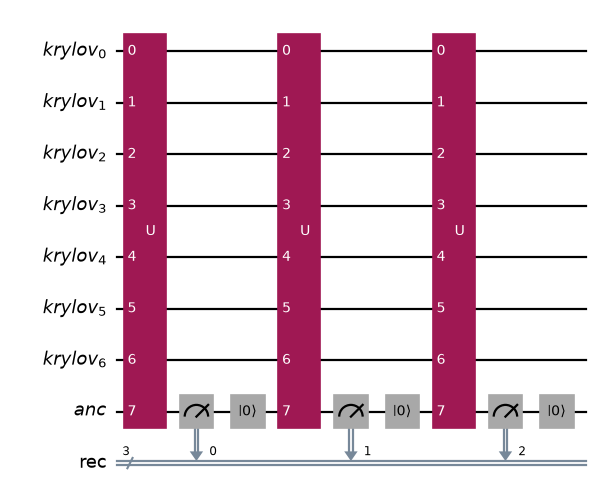

  8 qubits, 100 applications of one gate, depth 300, 300 instructions


In [ ]:
qc3 = build_circuit(grid, 3, save_states=False)
fig = qc3.draw('mpl', fold=-1, scale=.8)
fig.savefig(f'{PIC}/circuit_N{N}.png', dpi=160, bbox_inches='tight')
display(fig)

qc_full = build_circuit(grid, N_STEPS, save_states=False)
print(f"  {grid['n_qubits']} qubits, {N_STEPS} applications of one gate, "
      f"depth {qc_full.depth()}, {len(qc_full.data)} instructions")

---

Die Abschnitte 10 bis 14 sowie 16 und 17 (Eichung, Konvergenz in $m$,
Robustheit, Vergleich mit dem Companion-Weg, lange Laeufe, Ablesung am Ende
und die Zusammenfassung) stehen jetzt in **`Parameterstudie.ipynb`**,
zusammen mit den Scans ueber $\delta$, $\lambda$, die ADO-Skalierung und die
Krylov-Dimension $m$.
